# Stock Market Feature Engineering
**Linh Pham - Feature Engineering Module**

**Project**: Stock Market Return Prediction

## Tasks:
1. Create lagged features (past 1-, 5-, 10-day returns)
2. Compute technical indicators (MA, RSI, MACD, Bollinger Bands)
3. Add volatility and volume-based metrics
4. Standardize/normalize features
5. Create final feature matrix (X) and target vector (y) for each stock

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
from sklearn.preprocessing import StandardScaler, RobustScaler

warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

## Configuration

In [2]:
# Configuration
import os

STOCK_LIST = ['AAPL', 'GOOGL', 'MSFT', 'AMZN', 'TSLA']

# Find project root automatically
def find_project_root():
    search_dir = os.getcwd()
    for _ in range(5):
        if (os.path.exists(os.path.join(search_dir, 'data', 'processed', 'combined_stock_data.csv')) or
            os.path.exists(os.path.join(search_dir, 'experiment')) or
            os.path.exists(os.path.join(search_dir, 'README.md'))):
            return search_dir
        parent_dir = os.path.dirname(search_dir)
        if parent_dir == search_dir:
            break
        search_dir = parent_dir
    return os.getcwd()

project_root = find_project_root()
os.chdir(project_root)

DATA_PATH = 'data/processed/combined_stock_data.csv'
OUTPUT_DIR = 'data/features'

# Feature engineering parameters
LAG_PERIODS = [1, 2, 3, 5, 10, 20]  # Days to look back
MA_WINDOWS = [5, 10, 20, 50]  # Moving average windows
VOL_WINDOWS = [5, 10, 20]  # Volatility windows

print("Configuration:")
print(f"  Stocks: {', '.join(STOCK_LIST)}")
print(f"  Data path: {DATA_PATH}")
print(f"  Output directory: {OUTPUT_DIR}")
print(f"  Lag periods: {LAG_PERIODS}")
print(f"  MA windows: {MA_WINDOWS}")
print(f"  Volatility windows: {VOL_WINDOWS}\n")

Configuration:
  Stocks: AAPL, GOOGL, MSFT, AMZN, TSLA
  Data path: data/processed/combined_stock_data.csv
  Output directory: data/features
  Lag periods: [1, 2, 3, 5, 10, 20]
  MA windows: [5, 10, 20, 50]
  Volatility windows: [5, 10, 20]



## Load Preprocessed Data

In [3]:
# Load the preprocessed data
print("Loading preprocessed data...")
df = pd.read_csv(DATA_PATH)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['symbol', 'date']).reset_index(drop=True)

print(f"  Shape: {df.shape}")
print(f"  Stocks: {df['symbol'].unique()}")
print(f"  Date range: {df['date'].min()} to {df['date'].max()}")
print(f"\nFirst few rows:")
df.head(10)

Loading preprocessed data...
  Shape: (6280, 9)
  Stocks: ['AAPL' 'AMZN' 'GOOGL' 'MSFT' 'TSLA']
  Date range: 2020-01-03 00:00:00 to 2024-12-30 00:00:00

First few rows:


,date,open,high,low,close,volume,symbol,log_return,next_day_return
0,2020-01-03,71.765659,72.594048,71.608677,71.833282,146322800,AAPL,-0.009770,0.007937
1,2020-01-06,70.954188,72.444321,70.703012,72.405678,118387200,AAPL,0.007937,-0.004714
2,2020-01-07,72.415330,72.671333,71.845362,72.065140,108872000,AAPL,-0.004714,0.015959
3,2020-01-08,71.768101,73.526318,71.768101,73.224426,132079200,AAPL,0.015959,0.021018
4,2020-01-09,74.202519,74.972947,73.951351,74.779739,170108400,AAPL,0.021018,0.002259
5,2020-01-10,75.014035,75.513970,74.446478,74.948822,140644800,AAPL,0.002259,0.021139
6,2020-01-13,75.265196,76.576611,75.146850,76.550041,121532000,AAPL,0.021139,-0.013595
7,2020-01-14,76.487245,76.697361,75.393191,75.516357,161954400,AAPL,-0.013595,-0.004295
8,2020-01-15,75.315908,76.197430,74.760423,75.192734,121923600,AAPL,-0.004295,0.012449
9,2020-01-16,75.736156,76.245753,75.373886,76.134651,108829200,AAPL,0.012449,0.011010


## Task 1: Create Lagged Features

Lagged features capture historical patterns and momentum in stock prices.

In [4]:
def create_lagged_features(df, lag_periods):
    """
    Create lagged return features for each stock.
    
    Args:
        df: DataFrame with stock data
        lag_periods: List of lag periods (e.g., [1, 5, 10])
    
    Returns:
        DataFrame with lagged features added
    """
    result_dfs = []
    
    for symbol in df['symbol'].unique():
        stock_df = df[df['symbol'] == symbol].copy()
        stock_df = stock_df.sort_values('date')
        
        # Create lagged returns
        for lag in lag_periods:
            stock_df[f'return_lag_{lag}'] = stock_df['log_return'].shift(lag)
        
        # Create lagged prices
        for lag in [1, 5, 10]:
            stock_df[f'close_lag_{lag}'] = stock_df['close'].shift(lag)
        
        # Create price ratios (current vs lagged)
        for lag in [5, 10, 20]:
            stock_df[f'price_ratio_{lag}'] = stock_df['close'] / stock_df['close'].shift(lag)
        
        result_dfs.append(stock_df)
    
    return pd.concat(result_dfs, axis=0).reset_index(drop=True)


print("Task 1: Creating lagged features...\n")
df_with_lags = create_lagged_features(df, LAG_PERIODS)

# Show new features
lag_features = [col for col in df_with_lags.columns if 'lag' in col or 'ratio' in col]
print(f"Created {len(lag_features)} lagged features:")
for feat in lag_features:
    print(f"  - {feat}")

print(f"\nDataFrame shape: {df_with_lags.shape}")
df_with_lags.head()

Task 1: Creating lagged features...

Created 12 lagged features:
  - return_lag_1
  - return_lag_2
  - return_lag_3
  - return_lag_5
  - return_lag_10
  - return_lag_20
  - close_lag_1
  - close_lag_5
  - close_lag_10
  - price_ratio_5
  - price_ratio_10
  - price_ratio_20

DataFrame shape: (6280, 21)


,date,open,high,low,close,volume,symbol,log_return,next_day_return,return_lag_1,return_lag_2,return_lag_3,return_lag_5,return_lag_10,return_lag_20,close_lag_1,close_lag_5,close_lag_10,price_ratio_5,price_ratio_10,price_ratio_20
0,2020-01-03,71.765659,72.594048,71.608677,71.833282,146322800,AAPL,-0.009770,0.007937,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2020-01-06,70.954188,72.444321,70.703012,72.405678,118387200,AAPL,0.007937,-0.004714,-0.009770,NaN,NaN,NaN,NaN,NaN,71.833282,NaN,NaN,NaN,NaN,NaN
2,2020-01-07,72.415330,72.671333,71.845362,72.065140,108872000,AAPL,-0.004714,0.015959,0.007937,-0.009770,NaN,NaN,NaN,NaN,72.405678,NaN,NaN,NaN,NaN,NaN
3,2020-01-08,71.768101,73.526318,71.768101,73.224426,132079200,AAPL,0.015959,0.021018,-0.004714,0.007937,-0.009770,NaN,NaN,NaN,72.065140,NaN,NaN,NaN,NaN,NaN
4,2020-01-09,74.202519,74.972947,73.951351,74.779739,170108400,AAPL,0.021018,0.002259,0.015959,-0.004714,0.007937,NaN,NaN,NaN,73.224426,NaN,NaN,NaN,NaN,NaN


## Task 2: Technical Indicators

Technical indicators are widely used in trading to identify trends and momentum.

In [5]:
def calculate_rsi(prices, period=14):
    """
    Calculate Relative Strength Index (RSI).
    RSI measures momentum and identifies overbought/oversold conditions.
    
    Args:
        prices: Series of closing prices
        period: Lookback period (default 14)
    
    Returns:
        RSI values (0-100)
    """
    delta = prices.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))
    return rsi


def calculate_macd(prices, fast=12, slow=26, signal=9):
    """
    Calculate MACD (Moving Average Convergence Divergence).
    MACD shows the relationship between two moving averages.
    
    Args:
        prices: Series of closing prices
        fast: Fast EMA period
        slow: Slow EMA period
        signal: Signal line period
    
    Returns:
        Tuple of (MACD line, Signal line, MACD histogram)
    """
    ema_fast = prices.ewm(span=fast, adjust=False).mean()
    ema_slow = prices.ewm(span=slow, adjust=False).mean()
    
    macd_line = ema_fast - ema_slow
    signal_line = macd_line.ewm(span=signal, adjust=False).mean()
    macd_histogram = macd_line - signal_line
    
    return macd_line, signal_line, macd_histogram


def calculate_bollinger_bands(prices, window=20, num_std=2):
    """
    Calculate Bollinger Bands.
    Bollinger Bands measure volatility and identify overbought/oversold levels.
    
    Args:
        prices: Series of closing prices
        window: Moving average window
        num_std: Number of standard deviations
    
    Returns:
        Tuple of (upper band, middle band, lower band, bandwidth, %B)
    """
    middle_band = prices.rolling(window=window).mean()
    std = prices.rolling(window=window).std()
    
    upper_band = middle_band + (num_std * std)
    lower_band = middle_band - (num_std * std)
    
    # Bandwidth: measures volatility
    bandwidth = (upper_band - lower_band) / middle_band
    
    # %B: position within bands
    percent_b = (prices - lower_band) / (upper_band - lower_band)
    
    return upper_band, middle_band, lower_band, bandwidth, percent_b


def add_technical_indicators(df, ma_windows):
    """
    Add all technical indicators to the dataframe.
    
    Args:
        df: DataFrame with stock data
        ma_windows: List of moving average windows
    
    Returns:
        DataFrame with technical indicators added
    """
    result_dfs = []
    
    for symbol in df['symbol'].unique():
        stock_df = df[df['symbol'] == symbol].copy()
        stock_df = stock_df.sort_values('date')
        
        # Simple Moving Averages (SMA)
        for window in ma_windows:
            stock_df[f'sma_{window}'] = stock_df['close'].rolling(window=window).mean()
            # Price relative to SMA
            stock_df[f'price_to_sma_{window}'] = stock_df['close'] / stock_df[f'sma_{window}']
        
        # Exponential Moving Averages (EMA)
        for window in [12, 26]:
            stock_df[f'ema_{window}'] = stock_df['close'].ewm(span=window, adjust=False).mean()
        
        # RSI
        stock_df['rsi_14'] = calculate_rsi(stock_df['close'], period=14)
        
        # MACD
        macd_line, signal_line, macd_hist = calculate_macd(stock_df['close'])
        stock_df['macd'] = macd_line
        stock_df['macd_signal'] = signal_line
        stock_df['macd_histogram'] = macd_hist
        
        # Bollinger Bands
        bb_upper, bb_middle, bb_lower, bb_bandwidth, bb_percent = calculate_bollinger_bands(stock_df['close'])
        stock_df['bb_upper'] = bb_upper
        stock_df['bb_middle'] = bb_middle
        stock_df['bb_lower'] = bb_lower
        stock_df['bb_bandwidth'] = bb_bandwidth
        stock_df['bb_percent'] = bb_percent
        
        # Momentum indicators
        stock_df['momentum_5'] = stock_df['close'] - stock_df['close'].shift(5)
        stock_df['momentum_10'] = stock_df['close'] - stock_df['close'].shift(10)
        
        # Rate of Change (ROC)
        stock_df['roc_5'] = (stock_df['close'] - stock_df['close'].shift(5)) / stock_df['close'].shift(5)
        stock_df['roc_10'] = (stock_df['close'] - stock_df['close'].shift(10)) / stock_df['close'].shift(10)
        
        result_dfs.append(stock_df)
    
    return pd.concat(result_dfs, axis=0).reset_index(drop=True)


print("Task 2: Adding technical indicators...\n")
df_with_tech = add_technical_indicators(df_with_lags, MA_WINDOWS)

# Show new features
tech_features = [col for col in df_with_tech.columns if any(x in col for x in ['sma', 'ema', 'rsi', 'macd', 'bb_', 'momentum', 'roc'])]
print(f"Created {len(tech_features)} technical indicator features:")
for feat in tech_features:
    print(f"  - {feat}")

print(f"\nDataFrame shape: {df_with_tech.shape}")

Task 2: Adding technical indicators...

Created 23 technical indicator features:
  - sma_5
  - price_to_sma_5
  - sma_10
  - price_to_sma_10
  - sma_20
  - price_to_sma_20
  - sma_50
  - price_to_sma_50
  - ema_12
  - ema_26
  - rsi_14
  - macd
  - macd_signal
  - macd_histogram
  - bb_upper
  - bb_middle
  - bb_lower
  - bb_bandwidth
  - bb_percent
  - momentum_5
  - momentum_10
  - roc_5
  - roc_10

DataFrame shape: (6280, 44)


## Task 3: Volatility and Volume-Based Metrics

Volatility measures risk and uncertainty, while volume indicates trading activity.

In [6]:
def add_volatility_volume_features(df, vol_windows):
    """
    Add volatility and volume-based features.
    
    Args:
        df: DataFrame with stock data
        vol_windows: List of volatility calculation windows
    
    Returns:
        DataFrame with volatility and volume features added
    """
    result_dfs = []
    
    for symbol in df['symbol'].unique():
        stock_df = df[df['symbol'] == symbol].copy()
        stock_df = stock_df.sort_values('date')
        
        # Historical volatility (standard deviation of returns)
        for window in vol_windows:
            stock_df[f'volatility_{window}'] = stock_df['log_return'].rolling(window=window).std()
            # Annualized volatility (assuming 252 trading days)
            stock_df[f'volatility_{window}_annualized'] = stock_df[f'volatility_{window}'] * np.sqrt(252)
        
        # Parkinson's volatility (uses high-low range)
        for window in vol_windows:
            hl_ratio = np.log(stock_df['high'] / stock_df['low'])
            stock_df[f'parkinson_vol_{window}'] = np.sqrt(
                (hl_ratio ** 2).rolling(window=window).mean() / (4 * np.log(2))
            )
        
        # Garman-Klass volatility (uses OHLC)
        for window in [10, 20]:
            hl = np.log(stock_df['high'] / stock_df['low']) ** 2
            co = np.log(stock_df['close'] / stock_df['open']) ** 2
            stock_df[f'gk_vol_{window}'] = np.sqrt(
                (0.5 * hl - (2 * np.log(2) - 1) * co).rolling(window=window).mean()
            )
        
        # Average True Range (ATR) - measure of volatility
        high_low = stock_df['high'] - stock_df['low']
        high_close = np.abs(stock_df['high'] - stock_df['close'].shift())
        low_close = np.abs(stock_df['low'] - stock_df['close'].shift())
        true_range = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
        stock_df['atr_14'] = true_range.rolling(window=14).mean()
        
        # Volume features
        for window in [5, 10, 20]:
            # Average volume
            stock_df[f'avg_volume_{window}'] = stock_df['volume'].rolling(window=window).mean()
            # Volume ratio (current vs average)
            stock_df[f'volume_ratio_{window}'] = stock_df['volume'] / stock_df[f'avg_volume_{window}']
        
        # Volume-weighted features
        stock_df['vwap_5'] = (
            (stock_df['close'] * stock_df['volume']).rolling(window=5).sum() / 
            stock_df['volume'].rolling(window=5).sum()
        )
        stock_df['price_to_vwap'] = stock_df['close'] / stock_df['vwap_5']
        
        # On-Balance Volume (OBV) - cumulative volume indicator
        obv = [0]
        for i in range(1, len(stock_df)):
            if stock_df['close'].iloc[i] > stock_df['close'].iloc[i-1]:
                obv.append(obv[-1] + stock_df['volume'].iloc[i])
            elif stock_df['close'].iloc[i] < stock_df['close'].iloc[i-1]:
                obv.append(obv[-1] - stock_df['volume'].iloc[i])
            else:
                obv.append(obv[-1])
        stock_df['obv'] = obv
        stock_df['obv_ema'] = stock_df['obv'].ewm(span=10, adjust=False).mean()
        
        # Intraday range features
        stock_df['daily_range'] = (stock_df['high'] - stock_df['low']) / stock_df['low']
        stock_df['close_to_high'] = (stock_df['high'] - stock_df['close']) / stock_df['high']
        stock_df['close_to_low'] = (stock_df['close'] - stock_df['low']) / stock_df['low']
        
        result_dfs.append(stock_df)
    
    return pd.concat(result_dfs, axis=0).reset_index(drop=True)


print("Task 3: Adding volatility and volume features...\n")
df_with_vol = add_volatility_volume_features(df_with_tech, VOL_WINDOWS)

# Show new features
vol_features = [col for col in df_with_vol.columns if any(x in col for x in ['volatility', 'vol_', 'atr', 'volume', 'vwap', 'obv', 'range', 'close_to'])]
print(f"Created {len(vol_features)} volatility and volume features:")
for feat in vol_features:
    print(f"  - {feat}")

print(f"\nDataFrame shape: {df_with_vol.shape}")

Task 3: Adding volatility and volume features...

Created 26 volatility and volume features:
  - volume
  - volatility_5
  - volatility_5_annualized
  - volatility_10
  - volatility_10_annualized
  - volatility_20
  - volatility_20_annualized
  - parkinson_vol_5
  - parkinson_vol_10
  - parkinson_vol_20
  - gk_vol_10
  - gk_vol_20
  - atr_14
  - avg_volume_5
  - volume_ratio_5
  - avg_volume_10
  - volume_ratio_10
  - avg_volume_20
  - volume_ratio_20
  - vwap_5
  - price_to_vwap
  - obv
  - obv_ema
  - daily_range
  - close_to_high
  - close_to_low

DataFrame shape: (6280, 69)


## Feature Summary and Quality Check

In [7]:
print("=" * 70)
print("Feature Engineering Summary")
print("=" * 70)

# Count features by category
all_features = df_with_vol.columns.tolist()
base_cols = ['date', 'open', 'high', 'low', 'close', 'volume', 'symbol', 'log_return', 'next_day_return']
engineered_features = [col for col in all_features if col not in base_cols]

print(f"\nTotal columns: {len(all_features)}")
print(f"Base columns: {len(base_cols)}")
print(f"Engineered features: {len(engineered_features)}")

# Categorize features
feature_categories = {
    'Lagged Returns': [f for f in engineered_features if 'return_lag' in f],
    'Lagged Prices': [f for f in engineered_features if 'close_lag' in f],
    'Price Ratios': [f for f in engineered_features if 'price_ratio' in f or 'price_to' in f],
    'Moving Averages': [f for f in engineered_features if 'sma' in f or 'ema' in f],
    'Momentum Indicators': [f for f in engineered_features if 'rsi' in f or 'momentum' in f or 'roc' in f],
    'MACD': [f for f in engineered_features if 'macd' in f],
    'Bollinger Bands': [f for f in engineered_features if 'bb_' in f],
    'Volatility': [f for f in engineered_features if 'volatility' in f or 'vol_' in f or 'atr' in f],
    'Volume': [f for f in engineered_features if 'volume' in f or 'vwap' in f or 'obv' in f],
    'Intraday': [f for f in engineered_features if 'range' in f or 'close_to' in f],
}

print("\nFeatures by category:")
for category, features in feature_categories.items():
    print(f"\n{category}: {len(features)} features")
    for feat in features[:5]:  # Show first 5
        print(f"  - {feat}")
    if len(features) > 5:
        print(f"  ... and {len(features) - 5} more")

# Check for missing values
print("\n" + "=" * 70)
print("Missing Values Analysis")
print("=" * 70)

missing_counts = df_with_vol[engineered_features].isnull().sum()
missing_pct = (missing_counts / len(df_with_vol) * 100)
missing_summary = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing %': missing_pct
})
missing_summary = missing_summary[missing_summary['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

if len(missing_summary) > 0:
    print(f"\nFeatures with missing values: {len(missing_summary)}")
    print(missing_summary.head(10))
else:
    print("\nNo missing values found!")

# Sample data preview
print("\n" + "=" * 70)
print("Sample Data (AAPL)")
print("=" * 70)
aapl_sample = df_with_vol[df_with_vol['symbol'] == 'AAPL'].tail(5)
print(aapl_sample[['date', 'close', 'next_day_return', 'rsi_14', 'macd', 'volatility_10', 'volume_ratio_5']].to_string())

Feature Engineering Summary

Total columns: 69
Base columns: 9
Engineered features: 60

Features by category:

Lagged Returns: 6 features
  - return_lag_1
  - return_lag_2
  - return_lag_3
  - return_lag_5
  - return_lag_10
  ... and 1 more

Lagged Prices: 3 features
  - close_lag_1
  - close_lag_5
  - close_lag_10

Price Ratios: 8 features
  - price_ratio_5
  - price_ratio_10
  - price_ratio_20
  - price_to_sma_5
  - price_to_sma_10
  ... and 3 more

Moving Averages: 11 features
  - sma_5
  - price_to_sma_5
  - sma_10
  - price_to_sma_10
  - sma_20
  ... and 6 more

Momentum Indicators: 5 features
  - rsi_14
  - momentum_5
  - momentum_10
  - roc_5
  - roc_10

MACD: 3 features
  - macd
  - macd_signal
  - macd_histogram

Bollinger Bands: 5 features
  - bb_upper
  - bb_middle
  - bb_lower
  - bb_bandwidth
  - bb_percent

Volatility: 12 features
  - volatility_5
  - volatility_5_annualized
  - volatility_10
  - volatility_10_annualized
  - volatility_20
  ... and 7 more

Volume: 10 feat

## Task 4: Feature Standardization and Normalization

Standardize features to have mean=0 and std=1 for better model performance.

In [8]:
def handle_missing_values(df):
    """Handle missing values by dropping initial incomplete rows."""
    base_cols = ['date', 'open', 'high', 'low', 'close', 'volume', 'symbol', 'log_return', 'next_day_return']
    engineered_features = [col for col in df.columns if col not in base_cols]
    
    print("Handling missing values...")
    print(f"Before: {len(df)} rows, {df[engineered_features].isnull().sum().sum()} missing values")
    
    result_dfs = []
    for symbol in df['symbol'].unique():
        stock_df = df[df['symbol'] == symbol].copy()
        stock_df = stock_df.sort_values('date')
        
        # Find first complete row (all engineered features non-null)
        complete_mask = stock_df[engineered_features].notnull().all(axis=1)
        if complete_mask.any():
            first_complete_idx = stock_df[complete_mask].index[0]
            stock_df_clean = stock_df.loc[first_complete_idx:].copy()
            result_dfs.append(stock_df_clean)
        else:
            result_dfs.append(stock_df)
    
    df_clean = pd.concat(result_dfs, axis=0).reset_index(drop=True)
    
    print(f"After: {len(df_clean)} rows, {df_clean[engineered_features].isnull().sum().sum()} missing values")
    print(f"Data retention: {len(df_clean)/len(df)*100:.1f}%")
    
    return df_clean

# Handle missing values
df_clean = handle_missing_values(df_with_vol)

Handling missing values...
Before: 6280 rows, 3005 missing values
After: 6035 rows, 0 missing values
Data retention: 96.1%


## Missing Value Handling

Handle missing values that occur at the beginning of the time series due to lagged features and moving averages.

In [9]:
def prepare_features_for_scaling(df):
    """
    Identify which features need scaling.
    
    Returns:
        List of feature names to scale
    """
    # Columns to exclude from scaling
    exclude_cols = ['date', 'symbol', 'next_day_return']
    
    # Base OHLCV columns (we'll keep original but also create scaled versions)
    base_cols = ['open', 'high', 'low', 'close', 'volume', 'log_return']
    
    # All other columns are engineered features
    all_cols = df.columns.tolist()
    features_to_scale = [col for col in all_cols if col not in exclude_cols]
    
    return features_to_scale


def scale_features_by_stock(df, features_to_scale):
    """
    Scale features separately for each stock to prevent data leakage.
    Uses RobustScaler which is less sensitive to outliers.
    
    Args:
        df: DataFrame with all features
        features_to_scale: List of feature names to scale
    
    Returns:
        DataFrame with scaled features, dictionary of scalers
    """
    result_dfs = []
    scalers = {}
    
    for symbol in df['symbol'].unique():
        stock_df = df[df['symbol'] == symbol].copy()
        stock_df = stock_df.sort_values('date')
        
        # Initialize scaler
        scaler = RobustScaler()  # RobustScaler is better for financial data with outliers
        
        # Since missing values are already handled, all rows should be complete
        scaler.fit(stock_df[features_to_scale])
        
        # Transform all data
        scaled_features = pd.DataFrame(
            scaler.transform(stock_df[features_to_scale]),
            index=stock_df.index,
            columns=[f"{col}_scaled" for col in features_to_scale]
        )
        
        # Combine original and scaled features
        stock_df = pd.concat([stock_df, scaled_features], axis=1)
        
        # Store scaler for later use
        scalers[symbol] = scaler
        
        result_dfs.append(stock_df)
    
    return pd.concat(result_dfs, axis=0).reset_index(drop=True), scalers


print("Task 4: Scaling features...\\n")

features_to_scale = prepare_features_for_scaling(df_clean)
print(f"Features to scale: {len(features_to_scale)}")

df_scaled, scalers = scale_features_by_stock(df_clean, features_to_scale)

print(f"\\nScaled DataFrame shape: {df_scaled.shape}")
print(f"Scalers created for: {list(scalers.keys())}")

# Verify scaling
scaled_cols = [col for col in df_scaled.columns if col.endswith('_scaled')]
print(f"\\nCreated {len(scaled_cols)} scaled features")

# Show scaling statistics for one stock
print("\\nScaling verification (AAPL):")
aapl_data = df_scaled[df_scaled['symbol'] == 'AAPL'].copy()

sample_scaled_features = [col for col in scaled_cols if 'return_lag_1_scaled' in col or 'rsi' in col or 'volatility_10' in col][:3]
for feat in sample_scaled_features:
    mean = aapl_data[feat].mean()
    std = aapl_data[feat].std()
    print(f"  {feat}: mean={mean:.4f}, std={std:.4f}")

Task 4: Scaling features...\n
Features to scale: 66
\nScaled DataFrame shape: (6035, 135)
Scalers created for: ['AAPL', 'AMZN', 'GOOGL', 'MSFT', 'TSLA']
\nCreated 66 scaled features
\nScaling verification (AAPL):
  return_lag_1_scaled: mean=-0.0043, std=0.9527
  rsi_14_scaled: mean=-0.0436, std=0.6701
  volatility_10_scaled: mean=0.1930, std=0.9789


## Task 5: Create Final Feature Matrix (X) and Target Vector (y)

Prepare the final dataset for model training.

In [10]:
def create_feature_matrix(df, use_scaled=True):
    """
    Create final feature matrix (X) and target vector (y) for each stock.
    
    Args:
        df: DataFrame with all features
        use_scaled: Whether to use scaled features (default True)
    
    Returns:
        Dictionary with stock symbols as keys, containing X, y, and dates
    """
    # Identify feature columns
    exclude_cols = ['date', 'symbol', 'next_day_return']
    
    if use_scaled:
        # Use only scaled features
        feature_cols = [col for col in df.columns if col.endswith('_scaled')]
    else:
        # Use original features
        feature_cols = [col for col in df.columns if col not in exclude_cols and not col.endswith('_scaled')]
    
    # Target variable
    target_col = 'next_day_return'
    
    stock_data = {}
    
    for symbol in df['symbol'].unique():
        stock_df = df[df['symbol'] == symbol].copy()
        stock_df = stock_df.sort_values('date')
        
        # Remove rows with missing target or features
        valid_mask = (
            stock_df[target_col].notnull() & 
            stock_df[feature_cols].notnull().all(axis=1)
        )
        
        stock_df_clean = stock_df[valid_mask].copy()
        
        # Create X and y
        X = stock_df_clean[feature_cols].values
        y = stock_df_clean[target_col].values
        dates = stock_df_clean['date'].values
        
        stock_data[symbol] = {
            'X': X,
            'y': y,
            'dates': dates,
            'feature_names': feature_cols,
            'n_samples': len(X),
            'n_features': len(feature_cols)
        }
    
    return stock_data


print("Task 5: Creating final feature matrices...\n")

# Create feature matrices with scaled features
stock_datasets = create_feature_matrix(df_scaled, use_scaled=True)

print("Feature matrices created for each stock:\n")
for symbol, data in stock_datasets.items():
    print(f"{symbol}:")
    print(f"  X shape: {data['X'].shape}")
    print(f"  y shape: {data['y'].shape}")
    print(f"  Date range: {data['dates'][0]} to {data['dates'][-1]}")
    print(f"  Features: {data['n_features']}")
    print(f"  Samples: {data['n_samples']}")
    print()

Task 5: Creating final feature matrices...

Feature matrices created for each stock:

AAPL:
  X shape: (1206, 66)
  y shape: (1206,)
  Date range: 2020-03-16T00:00:00.000000000 to 2024-12-27T00:00:00.000000000
  Features: 66
  Samples: 1206

AMZN:
  X shape: (1206, 66)
  y shape: (1206,)
  Date range: 2020-03-16T00:00:00.000000000 to 2024-12-27T00:00:00.000000000
  Features: 66
  Samples: 1206

GOOGL:
  X shape: (1206, 66)
  y shape: (1206,)
  Date range: 2020-03-16T00:00:00.000000000 to 2024-12-27T00:00:00.000000000
  Features: 66
  Samples: 1206

MSFT:
  X shape: (1206, 66)
  y shape: (1206,)
  Date range: 2020-03-16T00:00:00.000000000 to 2024-12-27T00:00:00.000000000
  Features: 66
  Samples: 1206

TSLA:
  X shape: (1206, 66)
  y shape: (1206,)
  Date range: 2020-03-16T00:00:00.000000000 to 2024-12-27T00:00:00.000000000
  Features: 66
  Samples: 1206



## Save Feature-Engineered Data

In [11]:
import pickle

print("Saving feature-engineered data...\n")

# Create output directory
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Save complete dataframe with all features
complete_path = f"{OUTPUT_DIR}/complete_features.csv"
df_scaled.to_csv(complete_path, index=False)
print(f"Complete dataset: {complete_path}")
print(f"  Shape: {df_scaled.shape}")
print(f"  Size: {os.path.getsize(complete_path) / 1024 / 1024:.2f} MB")

# Save individual stock datasets
for symbol in STOCK_LIST:
    stock_path = f"{OUTPUT_DIR}/{symbol}_features.csv"
    stock_df = df_scaled[df_scaled['symbol'] == symbol]
    stock_df.to_csv(stock_path, index=False)
    print(f"\n{symbol}: {stock_path}")
    print(f"  Rows: {len(stock_df)}")

# Save feature matrices as numpy arrays
for symbol, data in stock_datasets.items():
    np.save(f"{OUTPUT_DIR}/{symbol}_X.npy", data['X'])
    np.save(f"{OUTPUT_DIR}/{symbol}_y.npy", data['y'])
    np.save(f"{OUTPUT_DIR}/{symbol}_dates.npy", data['dates'])

print(f"\nNumpy arrays saved for all stocks")

# Save scalers
scaler_path = f"{OUTPUT_DIR}/scalers.pkl"
with open(scaler_path, 'wb') as f:
    pickle.dump(scalers, f)
print(f"\nScalers: {scaler_path}")

# Save feature names
feature_names_path = f"{OUTPUT_DIR}/feature_names.txt"
with open(feature_names_path, 'w') as f:
    for feat in stock_datasets['AAPL']['feature_names']:
        f.write(f"{feat}\n")
print(f"Feature names: {feature_names_path}")

# Save metadata
metadata = {
    'stocks': STOCK_LIST,
    'n_features': stock_datasets['AAPL']['n_features'],
    'feature_names': stock_datasets['AAPL']['feature_names'],
    'lag_periods': LAG_PERIODS,
    'ma_windows': MA_WINDOWS,
    'vol_windows': VOL_WINDOWS,
    'scaling_method': 'RobustScaler',
}

metadata_path = f"{OUTPUT_DIR}/metadata.pkl"
with open(metadata_path, 'wb') as f:
    pickle.dump(metadata, f)
print(f"Metadata: {metadata_path}")

Saving feature-engineered data...

Complete dataset: data/features/complete_features.csv
  Shape: (6035, 135)
  Size: 14.75 MB

AAPL: data/features/AAPL_features.csv
  Rows: 1207

GOOGL: data/features/GOOGL_features.csv
  Rows: 1207

MSFT: data/features/MSFT_features.csv
  Rows: 1207

AMZN: data/features/AMZN_features.csv
  Rows: 1207

TSLA: data/features/TSLA_features.csv
  Rows: 1207

Numpy arrays saved for all stocks

Scalers: data/features/scalers.pkl
Feature names: data/features/feature_names.txt
Metadata: data/features/metadata.pkl


## Feature Analysis and Visualization

Analyzing feature correlations with target (AAPL)...

Top 20 features by correlation with next_day_return:
obv_scaled             0.087077
obv_ema_scaled         0.080656
open_scaled            0.070110
high_scaled            0.069632
close_scaled           0.069411
close_lag_1_scaled     0.068121
low_scaled             0.067238
vwap_5_scaled          0.066886
sma_5_scaled           0.066829
ema_12_scaled          0.066680
sma_10_scaled          0.066473
close_lag_5_scaled     0.066456
bb_upper_scaled        0.065888
bb_middle_scaled       0.065665
sma_20_scaled          0.065665
ema_26_scaled          0.065535
close_lag_10_scaled    0.065214
bb_lower_scaled        0.064911
return_lag_5_scaled    0.063636
sma_50_scaled          0.063021
dtype: float64


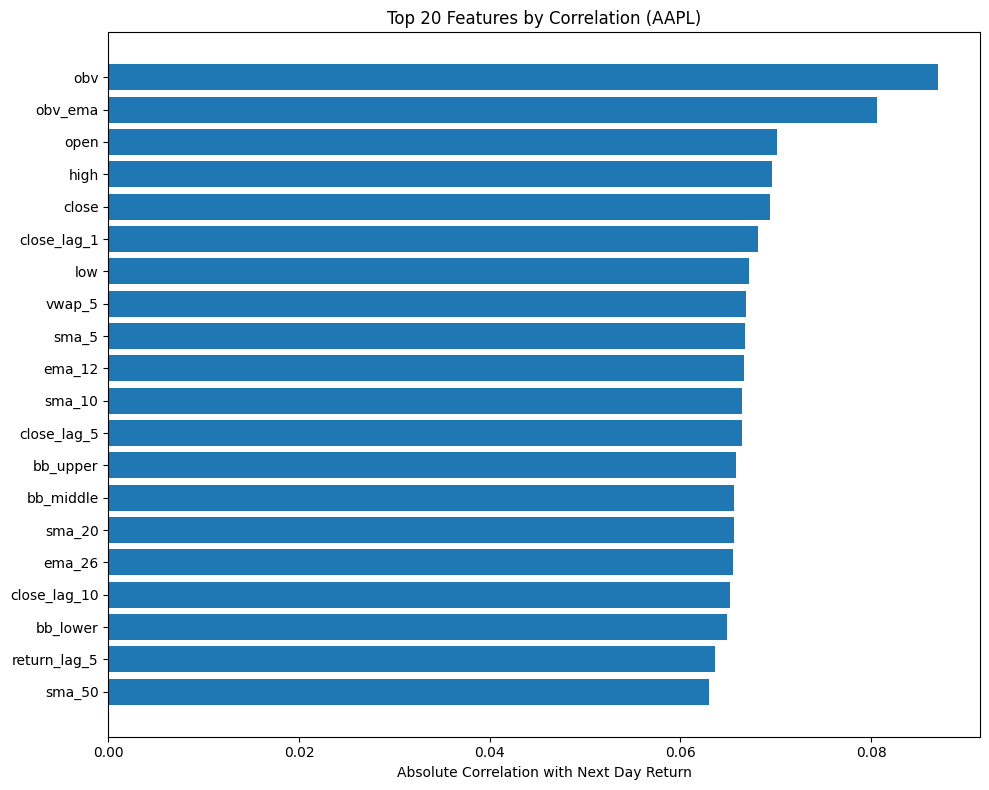


Visualization saved: data/features/feature_correlations.png


In [12]:
# Correlation analysis for AAPL
print("Analyzing feature correlations with target (AAPL)...\n")

aapl_data = df_scaled[df_scaled['symbol'] == 'AAPL'].copy()
feature_cols = [col for col in aapl_data.columns if col.endswith('_scaled')]

# Remove rows with missing values
aapl_clean = aapl_data[['next_day_return'] + feature_cols].dropna()

# Calculate correlations with target
correlations = aapl_clean[feature_cols].corrwith(aapl_clean['next_day_return']).abs().sort_values(ascending=False)

print("Top 20 features by correlation with next_day_return:")
print(correlations.head(20))

# Visualize top correlations
plt.figure(figsize=(10, 8))
top_features = correlations.head(20)
plt.barh(range(len(top_features)), top_features.values)
plt.yticks(range(len(top_features)), [name.replace('_scaled', '') for name in top_features.index])
plt.xlabel('Absolute Correlation with Next Day Return')
plt.title('Top 20 Features by Correlation (AAPL)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/feature_correlations.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nVisualization saved: {OUTPUT_DIR}/feature_correlations.png")

## Feature Distribution Visualization

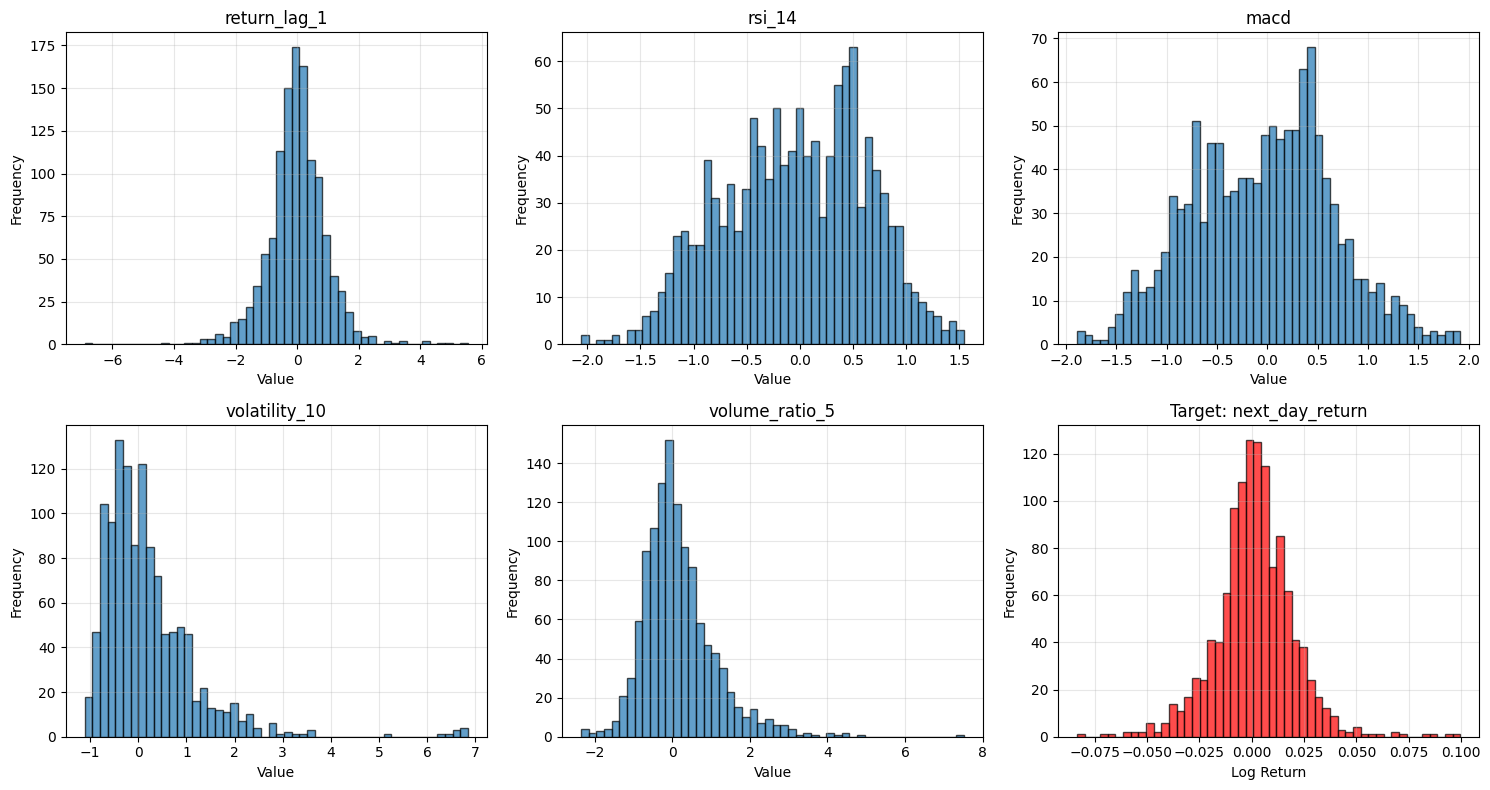

Distribution visualization saved: data/features/feature_distributions.png


In [13]:
# Visualize distributions of key features
key_features = ['return_lag_1_scaled', 'rsi_14_scaled', 'macd_scaled', 'volatility_10_scaled', 'volume_ratio_5_scaled']
available_features = [f for f in key_features if f in aapl_clean.columns]

if available_features:
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    axes = axes.flatten()
    
    for idx, feature in enumerate(available_features):
        if idx < len(axes):
            axes[idx].hist(aapl_clean[feature], bins=50, alpha=0.7, edgecolor='black')
            axes[idx].set_title(feature.replace('_scaled', ''))
            axes[idx].set_xlabel('Value')
            axes[idx].set_ylabel('Frequency')
            axes[idx].grid(True, alpha=0.3)
    
    # Target distribution
    if len(available_features) < len(axes):
        axes[len(available_features)].hist(aapl_clean['next_day_return'], bins=50, alpha=0.7, edgecolor='black', color='red')
        axes[len(available_features)].set_title('Target: next_day_return')
        axes[len(available_features)].set_xlabel('Log Return')
        axes[len(available_features)].set_ylabel('Frequency')
        axes[len(available_features)].grid(True, alpha=0.3)
    
    # Hide unused subplots
    for idx in range(len(available_features) + 1, len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/feature_distributions.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"Distribution visualization saved: {OUTPUT_DIR}/feature_distributions.png")

## Summary Report

In [14]:
print("\nDeliverables:")
print(f"  1. Complete feature dataset: {OUTPUT_DIR}/complete_features.csv")
print(f"  2. Individual stock datasets: {OUTPUT_DIR}/[STOCK]_features.csv")
print(f"  3. Feature matrices (X, y): {OUTPUT_DIR}/[STOCK]_X.npy, {OUTPUT_DIR}/[STOCK]_y.npy")
print(f"  4. Scalers: {OUTPUT_DIR}/scalers.pkl")
print(f"  5. Feature metadata: {OUTPUT_DIR}/metadata.pkl")
print(f"  6. Visualizations: {OUTPUT_DIR}/feature_correlations.png, feature_distributions.png")

print("\nFeature Engineering Summary:")
print(f"  Total features created: {len(feature_cols)}")
print(f"  Stocks processed: {len(STOCK_LIST)}")

print("\nDataset Statistics:")
for symbol, data in stock_datasets.items():
    print(f"\n  {symbol}:")
    print(f"    Samples: {data['n_samples']}")
    print(f"    Features: {data['n_features']}")
    print(f"    Target mean: {data['y'].mean():.6f}")
    print(f"    Target std: {data['y'].std():.6f}")



Deliverables:
  1. Complete feature dataset: data/features/complete_features.csv
  2. Individual stock datasets: data/features/[STOCK]_features.csv
  3. Feature matrices (X, y): data/features/[STOCK]_X.npy, data/features/[STOCK]_y.npy
  4. Scalers: data/features/scalers.pkl
  5. Feature metadata: data/features/metadata.pkl
  6. Visualizations: data/features/feature_correlations.png, feature_distributions.png

Feature Engineering Summary:
  Total features created: 66
  Stocks processed: 5

Dataset Statistics:

  AAPL:
    Samples: 1206
    Features: 66
    Target mean: 0.001207
    Target std: 0.018513

  AMZN:
    Samples: 1206
    Features: 66
    Target mean: 0.000799
    Target std: 0.022411

  GOOGL:
    Samples: 1206
    Features: 66
    Target mean: 0.001057
    Target std: 0.019723

  MSFT:
    Samples: 1206
    Features: 66
    Target mean: 0.000983
    Target std: 0.017605

  TSLA:
    Samples: 1206
    Features: 66
    Target mean: 0.002192
    Target std: 0.040515
